In [37]:
import pandas as pd
df = pd.read_csv(r"D:\Fraud detection dataset\creditcard.csv")  
df.head()



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [38]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

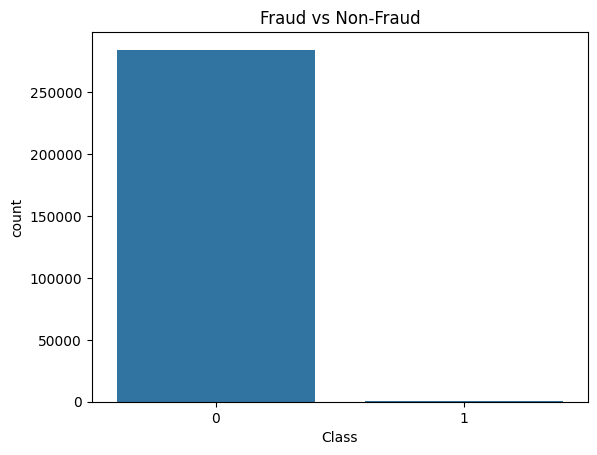

Class
0    284315
1       492
Name: count, dtype: int64


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

print(df['Class'].value_counts())


In [40]:
df['Hour'] = (df['Time'] // 3600) % 24


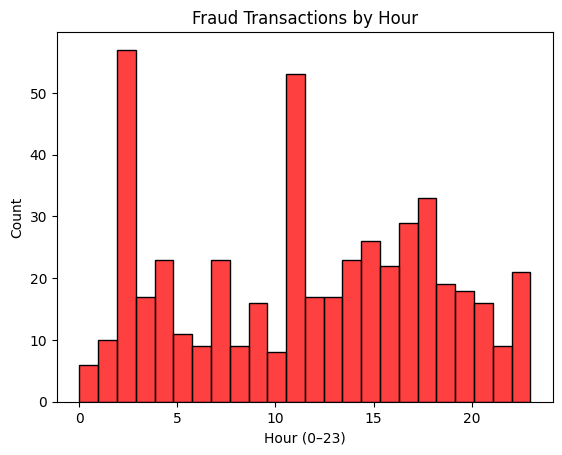

In [41]:
sns.histplot(df[df['Class'] == 1]['Hour'], bins=24, kde=False, color='red')
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour (0–23)")
plt.show()


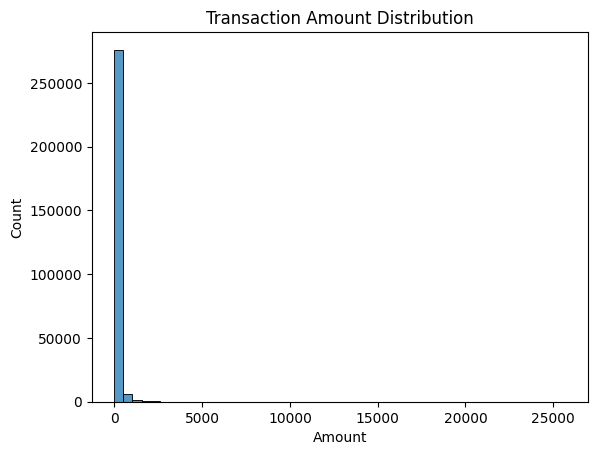

In [42]:


sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()



In [43]:
df['high_amount'] = df['Amount'].apply(lambda x: 1 if x > 200 else 0)


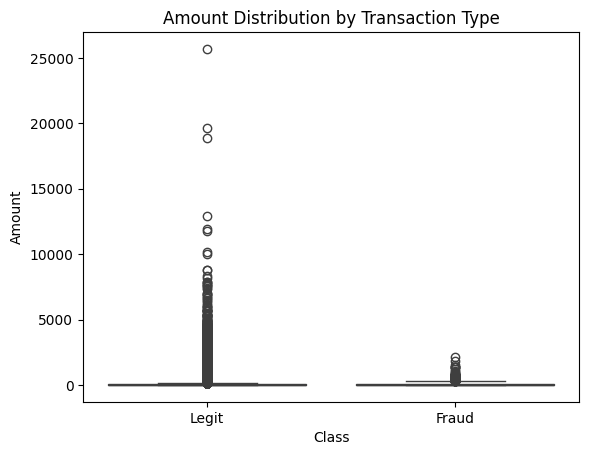

In [44]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount Distribution by Transaction Type")
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.show()




In [45]:
#from imblearn.over_sampling import SMOTE
#from sklearn.model_selection import train_test_split


# Use 3 features only for simplicity
#X = df[['Amount', 'Hour', 'HighAmount']]
#y = df['Class']

# Split and balance
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train_res, y_train_res = SMOTE().fit_resample(X_train, y_train)*/
from sklearn.model_selection import train_test_split
X = df[['Amount', 'Hour', 'high_amount']]
y = df['Class']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [46]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [47]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_resampled, y_train_resampled)







LogisticRegression()

In [48]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_resampled, y_train_resampled)





DecisionTreeClassifier()

In [49]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [50]:
# Predict and evaluate
for model, name in zip([lr, dt, xgb], ["Logistic Regression", "Decision Tree", "XGBoost"]):
    print(f"\n{name}:")
    y_pred = model.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    y_prob = model.predict_proba(X_test)[:, 1]
    print("AUC-ROC:", roc_auc_score(y_test, y_prob))


Logistic Regression:
[[35083 21781]
 [   47    51]]
              precision    recall  f1-score   support

           0       1.00      0.62      0.76     56864
           1       0.00      0.52      0.00        98

    accuracy                           0.62     56962
   macro avg       0.50      0.57      0.38     56962
weighted avg       1.00      0.62      0.76     56962

AUC-ROC: 0.5885287165654107

Decision Tree:
[[55004  1860]
 [   68    30]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.02      0.31      0.03        98

    accuracy                           0.97     56962
   macro avg       0.51      0.64      0.51     56962
weighted avg       1.00      0.97      0.98     56962

AUC-ROC: 0.6681582910316631

XGBoost:
[[53222  3642]
 [   60    38]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.01      0.39      0

In [27]:
y_pred = xgb.predict(X_test)  # or dt.predict(...), lr.predict(...)


In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[53222  3642]
 [   60    38]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.01      0.39      0.02        98

    accuracy                           0.94     56962
   macro avg       0.50      0.66      0.49     56962
weighted avg       1.00      0.94      0.96     56962



In [29]:
y_probs = xgb.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, y_probs)
print("AUC-ROC:", roc_score)


AUC-ROC: 0.7373234958023727


In [51]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define your model and parameter grid
xgb = XGBClassifier()
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1]
}

# Grid search
grid = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='f1', cv=3)
grid.fit(X_train_resampled, y_train_resampled)

# Best model
best_model = grid.best_estimator_


In [52]:
y_pred = best_model.predict(X_test)


In [32]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[53168  3696]
 [   60    38]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.01      0.39      0.02        98

    accuracy                           0.93     56962
   macro avg       0.50      0.66      0.49     56962
weighted avg       1.00      0.93      0.96     56962



In [33]:
from sklearn.metrics import roc_auc_score

y_probs = best_model.predict_proba(X_test)[:, 1]
print("AUC-ROC Score:", roc_auc_score(y_test, y_probs))


AUC-ROC Score: 0.7355901262446454


In [34]:
from sklearn.pipeline import Pipeline
import numpy as np

# Best model from GridSearch
model = best_model  # already trained

# Make a real-time prediction
# Example: Amount = 500, Hour = 2
amount = 500
hour = 2
high_amount = 1 if amount > 200 else 0

# Create feature array (2D)
features = np.array([[amount, hour, high_amount]])

# Predict
prediction = model.predict(features)

# Result
if prediction[0] == 1:
    print("🚨 Fraud Detected!")
else:
    print("✅ Legitimate Transaction")


✅ Legitimate Transaction


In [35]:
import joblib

# Save the best model to file
joblib.dump(best_model, "fraud_detection_model.pkl")


['fraud_detection_model.pkl']